# Vector 11: APP Romance / Investment Swarm
**Surface:** Human & Social | **Target:** Real-Time Payments | **Defense:** XGBoost Tabular Classifier

---
**Mastercard Innovation Challenge 2026** — AI Red-Team / Blue-Team Defense Lab  
Attack: A coordinated swarm of GenAI-driven social media personas progressively grooms victims into Authorised Push Payment (APP) fraud — either through fabricated romantic relationships or guaranteed high-yield investment schemes. Each persona adapts its engagement strategy based on victim behaviour, and payments are collected via real-time payment rails before the victim can reverse them.

## Section 1 — Simulation Engine
Generate 1 000 synthetic APP session records: 500 legitimate peer-to-peer payments and 500 adversarial romance/investment swarm transactions.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 500

# --- Legitimate peer-to-peer payment sessions ---
legit = {
    'account_age_days':          np.clip(np.random.normal(820, 300, N), 30, 3000),
    'message_velocity_per_hour': np.clip(np.random.normal(0.8, 0.4, N), 0.1, 5),
    'investment_yield_promise':  np.clip(np.random.beta(1, 15, N), 0, 1),
    'cross_border_flag':         np.random.binomial(1, 0.08, N).astype(float),
    'amount_escalation_rate':    np.clip(np.random.normal(0.04, 0.03, N), 0, 0.5),
    'swarm_account_similarity':  np.clip(np.random.beta(1, 10, N), 0, 1),
    'romantic_keyword_density':  np.clip(np.random.beta(1, 12, N), 0, 1),
    'victim_engagement_hours':   np.clip(np.random.normal(12, 5, N), 0.5, 48),
}

# --- Adversarial APP swarm sessions ---
adv = {
    'account_age_days':          np.clip(np.random.normal(18, 12, N), 1, 90),
    'message_velocity_per_hour': np.clip(np.random.normal(14, 5, N), 1, 60),
    'investment_yield_promise':  np.clip(np.random.beta(7, 2, N), 0, 1),
    'cross_border_flag':         np.random.binomial(1, 0.72, N).astype(float),
    'amount_escalation_rate':    np.clip(np.random.normal(0.65, 0.18, N), 0, 1),
    'swarm_account_similarity':  np.clip(np.random.beta(8, 2, N), 0, 1),
    'romantic_keyword_density':  np.clip(np.random.beta(6, 2, N), 0, 1),
    'victim_engagement_hours':   np.clip(np.random.normal(78, 24, N), 10, 200),
}

df_legit = pd.DataFrame(legit); df_legit['label'] = 0
df_adv   = pd.DataFrame(adv);   df_adv['label']   = 1
df = pd.concat([df_legit, df_adv], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
df.describe().round(3)

Dataset shape: (1000, 9)
Label distribution:
label
1    500
0    500
Name: count, dtype: int64


,account_age_days,message_velocity_per_hour,investment_yield_promise,cross_border_flag,amount_escalation_rate,swarm_account_similarity,romantic_keyword_density,victim_engagement_hours,label
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.0
mean,420.175,7.357,0.422,0.387,0.343,0.440,0.421,44.851,0.5
std,452.752,7.581,0.371,0.487,0.326,0.369,0.359,37.689,0.5
min,1.000,0.100,0.000,0.000,0.000,0.001,0.000,0.500,0.0
25%,17.264,0.811,0.051,0.000,0.038,0.064,0.052,11.730,0.0
50%,48.818,1.827,0.338,0.000,0.124,0.401,0.337,23.084,0.5
75%,823.808,13.840,0.796,1.000,0.644,0.816,0.780,78.681,1.0
max,1975.819,31.645,0.993,1.000,1.000,0.998,0.985,157.223,1.0


## Section 2 — Distribution Visualization
Overlapping KDE plots for `account_age_days` and `amount_escalation_rate`, plus a bar chart for binary flag counts.

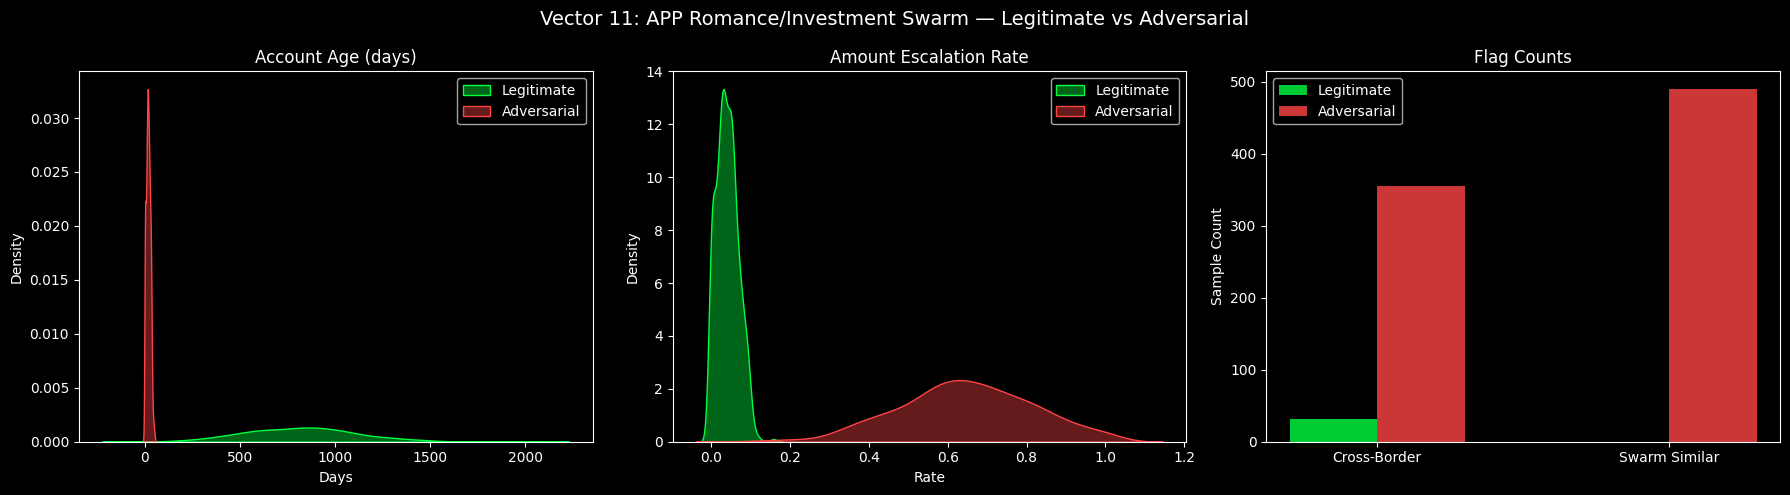

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
LEGIT_COLOR = '#00FF41'
ADV_COLOR   = '#FF4444'

legit_df = df[df['label'] == 0]
adv_df   = df[df['label'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Vector 11: APP Romance/Investment Swarm — Legitimate vs Adversarial', fontsize=14, color='white')

sns.kdeplot(legit_df['account_age_days'], ax=axes[0], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Legitimate')
sns.kdeplot(adv_df['account_age_days'],   ax=axes[0], color=ADV_COLOR,   fill=True, alpha=0.4, label='Adversarial')
axes[0].set_title('Account Age (days)', color='white')
axes[0].set_xlabel('Days')
axes[0].legend()

sns.kdeplot(legit_df['amount_escalation_rate'], ax=axes[1], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Legitimate')
sns.kdeplot(adv_df['amount_escalation_rate'],   ax=axes[1], color=ADV_COLOR,   fill=True, alpha=0.4, label='Adversarial')
axes[1].set_title('Amount Escalation Rate', color='white')
axes[1].set_xlabel('Rate')
axes[1].legend()

flags_legit = [legit_df['cross_border_flag'].sum(), (legit_df['swarm_account_similarity'] > 0.5).sum()]
flags_adv   = [adv_df['cross_border_flag'].sum(),   (adv_df['swarm_account_similarity']   > 0.5).sum()]
x = range(2); w = 0.3
axes[2].bar([i - w/2 for i in x], flags_legit, w, color=LEGIT_COLOR, alpha=0.8, label='Legitimate')
axes[2].bar([i + w/2 for i in x], flags_adv,   w, color=ADV_COLOR,   alpha=0.8, label='Adversarial')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(['Cross-Border', 'Swarm Similar'])
axes[2].set_title('Flag Counts', color='white')
axes[2].set_ylabel('Sample Count')
axes[2].legend()

plt.tight_layout()
plt.show()

## Section 3 — Blue Team Mitigation (XGBoost Tabular Classifier)

> **Production model:** `xgboost.XGBClassifier` — high AUC on structured APP session metadata.  **Runnable proxy:** `sklearn.ensemble.HistGradientBoostingClassifier` — functionally equivalent gradient boosting, no system-level dependency required.

In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

FEATURES = [
    'account_age_days', 'message_velocity_per_hour', 'investment_yield_promise',
    'cross_border_flag', 'amount_escalation_rate',
    'swarm_account_similarity', 'romantic_keyword_density', 'victim_engagement_hours'
]

X = df[FEATURES].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print(f'Train samples: {len(X_train)} | Test samples: {len(X_test)}')
print('HistGBM (XGBoost proxy) model trained successfully.')

Train samples: 800 | Test samples: 200
HistGBM (XGBoost proxy) model trained successfully.


## Section 4 — Performance Stats
Confusion matrix, classification report, and ROC-AUC curve. Targets: **AUC ≥ 0.97**, **FPR < 0.1%** at the operating threshold.

AUC: 1.0000
FPR at optimal threshold (1.0000): 0.0000%

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       100
 Adversarial       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



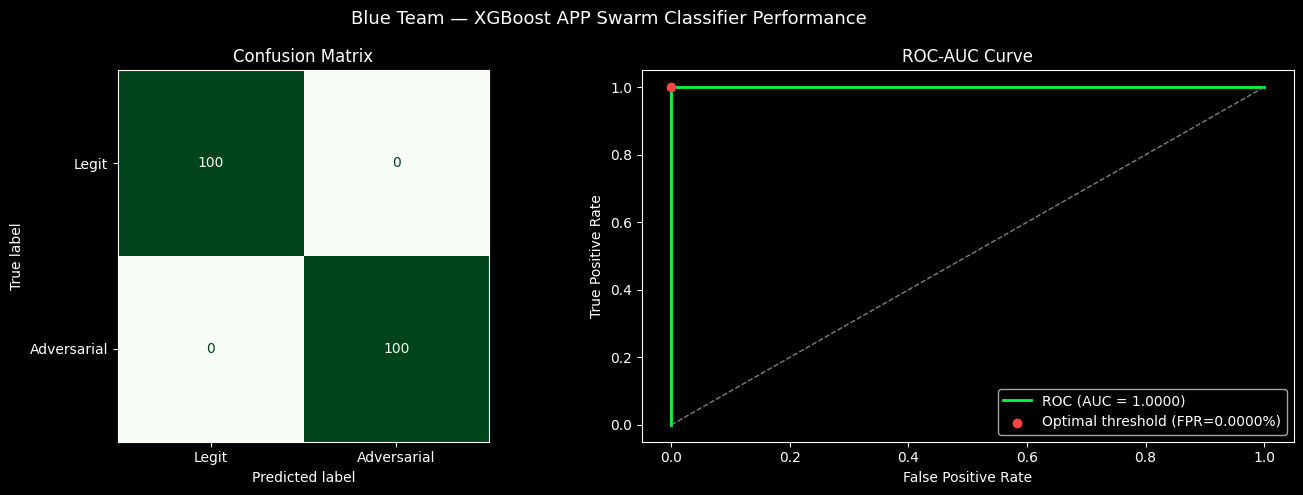

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_proba)

j_scores   = tpr_arr - fpr_arr
opt_idx    = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
opt_fpr    = fpr_arr[opt_idx]

print(f'AUC: {auc:.4f}')
print(f'FPR at optimal threshold ({opt_thresh:.4f}): {opt_fpr*100:.4f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Adversarial']))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Blue Team — XGBoost APP Swarm Classifier Performance', fontsize=13, color='white')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Adversarial'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix', color='white')
axes[0].title.set_color('white')

axes[1].plot(fpr_arr, tpr_arr, color='#00FF41', lw=2, label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].scatter([opt_fpr], [tpr_arr[opt_idx]], color='#FF4444', zorder=5,
                label=f'Optimal threshold (FPR={opt_fpr*100:.4f}%)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-AUC Curve', color='white')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Section 5 — Co-Evolution Loop
5 epochs: the swarm ages accounts and reduces escalation rate to mimic organic P2P behaviour. The Blue Team retrains on detected swarm samples, closing each evasion gap.

Epoch 0 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 800
Epoch 1 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 900
Epoch 2 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 1000
Epoch 3 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 1100
Epoch 4 | AUC: 1.0000 | Evasion Rate: 2.0% | Train size: 1200
Epoch 5 | AUC: 1.0000 | Evasion Rate: 26.0% | Train size: 1300

 Epoch  Train Size    AUC Evasion Rate
     0         800 1.0000         0.0%
     1         900 1.0000         0.0%
     2        1000 1.0000         0.0%
     3        1100 1.0000         0.0%
     4        1200 1.0000         2.0%
     5        1300 1.0000        26.0%


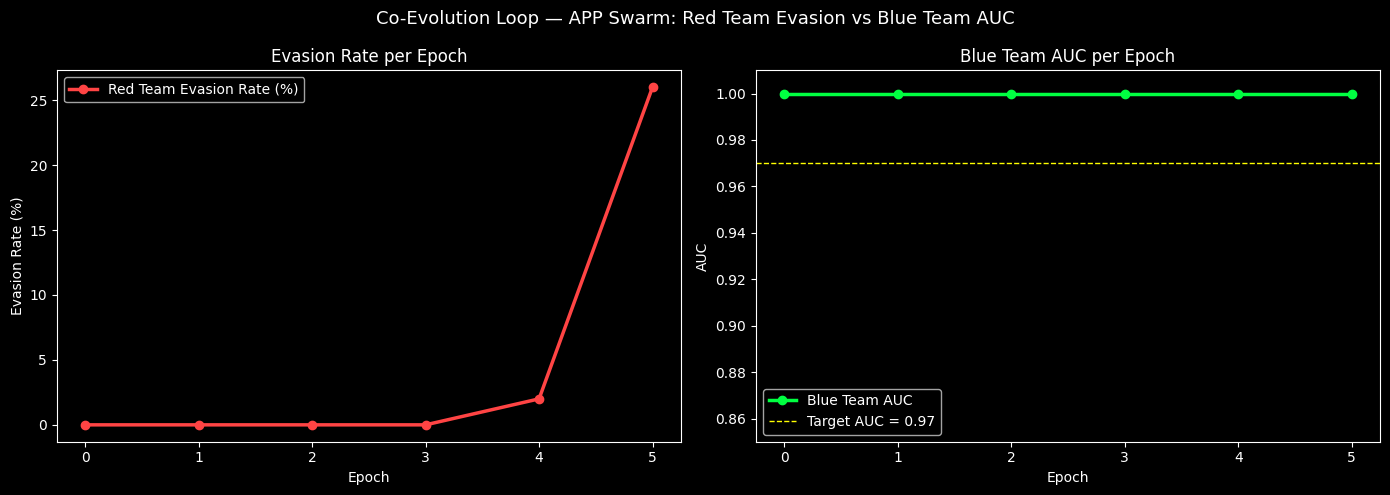

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

np.random.seed(0)
X_train_loop = X_train.copy().tolist()
y_train_loop = y_train.copy().tolist()

evasion_rates = []
auc_scores    = []
epoch_records = []

def make_evasive_swarm(n=100, epoch=1):
    """Swarm ages accounts and reduces obvious escalation signals."""
    t = epoch / 5.0
    samples = []
    for _ in range(n):
        acc_age   = np.clip(np.random.normal(18 + t * 400, 30), 1, 3000)
        msg_vel   = np.clip(np.random.normal(14 - t * 10, 3), 0.1, 60)
        yield_p   = np.clip(np.random.beta(max(1, 7 - t * 6), 2), 0, 1)
        cross_b   = float(np.random.binomial(1, max(0.08, 0.72 - t * 0.6)))
        esc_rate  = np.clip(np.random.normal(max(0.04, 0.65 - t * 0.55), 0.1), 0, 1)
        swarm_sim = np.clip(np.random.beta(max(1, 8 - t * 7), 2), 0, 1)
        rom_kw    = np.clip(np.random.beta(max(1, 6 - t * 5), 2), 0, 1)
        eng_hrs   = np.clip(np.random.normal(78 - t * 60, 15), 0.5, 200)
        samples.append([acc_age, msg_vel, yield_p, cross_b, esc_rate, swarm_sim, rom_kw, eng_hrs])
    return np.array(samples)

for epoch in range(6):
    m = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=epoch)
    m.fit(np.array(X_train_loop), np.array(y_train_loop))

    proba_test = m.predict_proba(X_test)[:, 1]
    epoch_auc  = roc_auc_score(y_test, proba_test)

    if epoch > 0:
        new_adv   = make_evasive_swarm(100, epoch)
        new_preds = m.predict(new_adv)
        evasion   = 1.0 - new_preds.mean()
        X_train_loop += new_adv.tolist()
        y_train_loop += [1] * len(new_adv)
    else:
        evasion = 0.0

    evasion_rates.append(evasion)
    auc_scores.append(epoch_auc)
    epoch_records.append({'Epoch': epoch, 'Train Size': len(X_train_loop),
                          'AUC': f'{epoch_auc:.4f}', 'Evasion Rate': f'{evasion*100:.1f}%'})
    print(f'Epoch {epoch} | AUC: {epoch_auc:.4f} | Evasion Rate: {evasion*100:.1f}% | Train size: {len(X_train_loop)}')

print()
print(pd.DataFrame(epoch_records).to_string(index=False))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Co-Evolution Loop — APP Swarm: Red Team Evasion vs Blue Team AUC', fontsize=13, color='white')

epochs_range = list(range(6))
axes[0].plot(epochs_range, [r * 100 for r in evasion_rates],
             color='#FF4444', lw=2.5, marker='o', label='Red Team Evasion Rate (%)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Evasion Rate (%)')
axes[0].set_title('Evasion Rate per Epoch', color='white')
axes[0].legend(); axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, auc_scores,
             color='#00FF41', lw=2.5, marker='o', label='Blue Team AUC')
axes[1].axhline(0.97, color='yellow', lw=1, linestyle='--', label='Target AUC = 0.97')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].set_title('Blue Team AUC per Epoch', color='white')
axes[1].set_ylim(0.85, 1.01)
axes[1].legend(); axes[1].set_xticks(epochs_range)

plt.tight_layout()
plt.show()